# Lookalike Modeling with Cortex Agent Skills

# Intelligent Lookalike Modeling with Cortex Agent Skills

**Objective:** Build a self-service lookalike modeling system where a Cortex Agent — equipped
with a SKILL.md-based skill — browses the Snowflake Feature Store, intelligently selects
and composes features, trains an XGBoost classifier, and scores a consumer universe. Then
build the data science team's monitoring layer to govern agent-created models at scale.

**Two-Sided Architecture:**
- **Part 1 (Sections 1-7):** Build the Feature Store, create the agent skill, deploy the
  agent, and invoke it 3 times with different seed audiences.
- **Part 2 (Sections 8-13):** Monitor agent-created models via experiment tracking, lift
  analysis, feature selection audit, drift detection, and quality gates.

**What you'll learn:**
1. Register governed feature views in the Snowflake Feature Store
2. Build a Cortex Agent skill (SKILL.md + Python scripts) for complex ML workflows
3. Combine LLM reasoning with statistical validation for feature selection
4. Train and register lookalike models via agent invocation
5. Monitor model quality with cumulative gains, lift analysis, and PSI
6. Apply automated quality gates to agent-created models

**Prerequisites:**
- `setup.sql` has been executed (creates database, schemas, and synthetic data)
- Database: `LOOKALIKE_DEMO` with schemas: RAW, FEATURE_STORE, MODELS, SCORING, MONITORING
- Snowflake ML packages installed in the notebook environment

## 1. Setup & Imports

In [1]:
# Core Snowpark
from snowflake.snowpark import Session
from snowflake.snowpark import functions as F
from snowflake.snowpark.types import StructType, StructField, StringType, FloatType, IntegerType
from snowflake.snowpark.window import Window

# Feature Store
from snowflake.ml.feature_store import FeatureStore, FeatureView, Entity

# Model Registry
from snowflake.ml.registry import Registry

# Experiment Tracking
from snowflake.ml.experiment import ExperimentTracking

# Modeling (server-side metrics only — model training runs in the agent's skill scripts)
from snowflake.ml.modeling.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score
)

# Standard
import pandas as pd
import numpy as np
import json
from datetime import datetime

In [2]:
# Get session — supports both Snowflake Notebooks (server-side) and local laptops
try:
    from snowflake.snowpark.context import get_active_session
    session = get_active_session()
except Exception:
    from snowflake.snowpark import Session
    session = Session.builder.config("connection_name", "parker_demo").create()

# Set context
session.sql("USE DATABASE LOOKALIKE_DEMO").collect()
session.sql("USE SCHEMA FEATURE_STORE").collect()
session.sql("USE WAREHOUSE LOOKALIKE_WH").collect()

print(f"Session established: {session.get_current_database()}.{session.get_current_schema()}")
print(f"Warehouse: {session.get_current_warehouse()}")

Session established: "LOOKALIKE_DEMO"."FEATURE_STORE"
Warehouse: "LOOKALIKE_WH"


## 2. Explore Source Data

Verify the setup script ran correctly and understand the data landscape.

In [3]:
# Check row counts for all source tables
tables = ['CONSUMER_UNIVERSE', 'PURCHASE_HISTORY', 'CHANNEL_ENGAGEMENT', 'CAMPAIGN_SEEDS']
for t in tables:
    count = session.table(f"LOOKALIKE_DEMO.RAW.{t}").count()
    print(f"  {t}: {count:,} rows")

print("\n--- Seed Audiences ---")
session.table("LOOKALIKE_DEMO.RAW.CAMPAIGN_SEEDS") \
    .group_by("SEED_NAME") \
    .agg(F.count("*").alias("SIZE"), F.max("SEED_DESCRIPTION").alias("DESCRIPTION")) \
    .order_by("SEED_NAME") \
    .show()

  CONSUMER_UNIVERSE: 100,000 rows
  PURCHASE_HISTORY: 500,000 rows
  CHANNEL_ENGAGEMENT: 300,000 rows
  CAMPAIGN_SEEDS: 1,903 rows

--- Seed Audiences ---
-------------------------------------------------------------------------------------------
|"SEED_NAME"                |"SIZE"  |"DESCRIPTION"                                       |
-------------------------------------------------------------------------------------------
|digital_first_millennials  |890     |Young professionals aged 25-34 in urban areas w...  |
|family_value_seekers       |673     |Families with 2+ children, moderate income, fre...  |
|home_garden_buyers         |340     |High-value Home & Garden purchasers: homeowners...  |
-------------------------------------------------------------------------------------------



In [4]:
# Understand universe demographics - these will become features
print("--- Age Group Distribution ---")
session.table("LOOKALIKE_DEMO.RAW.CONSUMER_UNIVERSE") \
    .group_by("AGE_GROUP").count().order_by("AGE_GROUP").show()

print("\n--- Income Distribution ---")
session.table("LOOKALIKE_DEMO.RAW.CONSUMER_UNIVERSE") \
    .group_by("INCOME_BRACKET").count().order_by("COUNT").show()

print("\n--- Purchase Categories ---")
session.table("LOOKALIKE_DEMO.RAW.PURCHASE_HISTORY") \
    .group_by("CATEGORY") \
    .agg(F.count("*").alias("PURCHASES"), F.sum("AMOUNT").alias("TOTAL_SPEND")) \
    .order_by(F.col("PURCHASES").desc()) \
    .show()

--- Age Group Distribution ---
-------------------------
|"AGE_GROUP"  |"COUNT"  |
-------------------------
|18-24        |13636    |
|25-34        |19251    |
|35-44        |19137    |
|45-54        |19144    |
|55-64        |19273    |
|65+          |9559     |
-------------------------


--- Income Distribution ---
------------------------------
|"INCOME_BRACKET"  |"COUNT"  |
------------------------------
|150k_plus         |7939     |
|100k-150k         |11973    |
|under_25k         |15126    |
|75k-100k          |19791    |
|25k-50k           |19988    |
|50k-75k           |25183    |
------------------------------


--- Purchase Categories ---
---------------------------------------------
|"CATEGORY"   |"PURCHASES"  |"TOTAL_SPEND"  |
---------------------------------------------
|electronics  |75118        |17085813.00    |
|home_garden  |75109        |13438512.00    |
|food         |74867        |6325190.00     |
|clothing     |74770        |6326947.00     |
|toys         |50

## 3. Feature Store Initialization

Create the Feature Store, define the CONSUMER entity, and prepare to register feature views. The Feature Store acts as the governed catalog that the agent will browse when selecting features for a lookalike model.

In [5]:
# Initialize the Feature Store (CREATE_IF_NOT_EXIST for first-time setup)
from snowflake.ml.feature_store import CreationMode

fs = FeatureStore(
    session=session,
    database="LOOKALIKE_DEMO",
    name="FEATURE_STORE",
    default_warehouse="LOOKALIKE_WH",
    creation_mode=CreationMode.CREATE_IF_NOT_EXIST
)

# Define the CONSUMER entity - the join key for all feature views
consumer_entity = Entity(
    name="CONSUMER",
    join_keys=["CONSUMER_ID"],
    desc="Individual consumer in the marketing universe"
)

# Register entity
fs.register_entity(consumer_entity)
print("Feature Store initialized and CONSUMER entity registered.")

Feature Store initialized and CONSUMER entity registered.


/Users/perickson/miniconda3/envs/customer_work/lib/python3.11/site-packages/snowflake/ml/feature_store/feature_store.py:211: UserWarning: Entity CONSUMER already exists. Skip registration.
  return f(self, *args, **kargs)


## 4. Register Feature Views

Register 5 feature views that form the governed feature catalog. Each view has per-feature descriptions so the agent can understand what's available when browsing.

### 4.1 Customer Demographics Feature View

In [6]:
# 4.1 Customer Demographics - static attributes from the universe table
demographics_df = session.table("LOOKALIKE_DEMO.RAW.CONSUMER_UNIVERSE").select(
    "CONSUMER_ID", "AGE", "AGE_GROUP", "GENDER", "INCOME_BRACKET",
    "HOMEOWNER", "MARITAL_STATUS", "CHILDREN_COUNT", "HOUSEHOLD_SIZE",
    "EDUCATION_LEVEL", "OCCUPATION_GROUP", "CREDIT_SCORE_RANGE",
    "CHANNEL_PREFERENCE", "EMAIL_OPT_IN", "MAIL_OPT_IN", "TENURE_MONTHS"
)

demographics_fv = FeatureView(
    name="CUSTOMER_DEMOGRAPHICS_FV",
    entities=[consumer_entity],
    feature_df=demographics_df,
    refresh_freq=None,  # External: updated outside Feature Store
    desc="Static consumer demographic and preference attributes"
)

demographics_fv = demographics_fv.attach_feature_desc({
    "AGE": "Consumer age in years",
    "AGE_GROUP": "Age bracket: 18-24, 25-34, 35-44, 45-54, 55-64, 65+",
    "GENDER": "Gender: M, F, NB",
    "INCOME_BRACKET": "Household income: under_25k, 25k-50k, 50k-75k, 75k-100k, 100k-150k, 150k_plus",
    "HOMEOWNER": "Homeownership status: Y or N",
    "MARITAL_STATUS": "Marital status: single, married, divorced, widowed",
    "CHILDREN_COUNT": "Number of children in household (0-3)",
    "HOUSEHOLD_SIZE": "Total household members",
    "EDUCATION_LEVEL": "Education: high_school, some_college, bachelors, masters, doctorate",
    "OCCUPATION_GROUP": "Occupation: professional, management, sales_service, technical, trades, retired",
    "CREDIT_SCORE_RANGE": "Credit tier: poor, fair, good, very_good, excellent",
    "CHANNEL_PREFERENCE": "Preferred contact channel: email, mail, digital, social",
    "EMAIL_OPT_IN": "Whether consumer opted in to email marketing",
    "MAIL_OPT_IN": "Whether consumer opted in to direct mail",
    "TENURE_MONTHS": "Months since consumer entered the database"
})

registered_demographics = fs.register_feature_view(
    feature_view=demographics_fv,
    version="1",
    block=True,
    overwrite=True
)
print(f"Registered: {registered_demographics.name} v{registered_demographics.version}")

Registered: CUSTOMER_DEMOGRAPHICS_FV v1


### 4.2 Purchase RFM Feature View

In [7]:
# 4.2 Purchase RFM - Recency, Frequency, Monetary computed from purchase history
rfm_df = session.table("LOOKALIKE_DEMO.RAW.PURCHASE_HISTORY").group_by("CONSUMER_ID").agg(
    F.datediff("day", F.max("PURCHASE_TS"), F.current_timestamp()).alias("RECENCY_DAYS"),
    F.count("*").alias("FREQUENCY_12M"),
    F.sum("AMOUNT").alias("MONETARY_12M"),
    F.avg("AMOUNT").alias("AVG_ORDER_VALUE"),
    F.count_distinct(F.date_trunc("month", F.col("PURCHASE_TS"))).alias("ACTIVE_MONTHS"),
    F.sum(F.when(F.col("COUPON_USED") == True, F.lit(1)).otherwise(F.lit(0))).alias("COUPON_USAGE_COUNT")
)

# Add purchase velocity (orders per active month)
rfm_df = rfm_df.with_column(
    "PURCHASE_VELOCITY",
    F.when(F.col("ACTIVE_MONTHS") > 0,
           F.round(F.col("FREQUENCY_12M") / F.col("ACTIVE_MONTHS"), 2)
    ).otherwise(F.lit(0.0))
)

rfm_fv = FeatureView(
    name="PURCHASE_RFM_FV",
    entities=[consumer_entity],
    feature_df=rfm_df,
    refresh_freq=None,
    desc="Purchase behavior features: recency, frequency, monetary value, and velocity"
)

rfm_fv = rfm_fv.attach_feature_desc({
    "RECENCY_DAYS": "Days since most recent purchase",
    "FREQUENCY_12M": "Total number of purchases in the last 12 months",
    "MONETARY_12M": "Total spend in USD over the last 12 months",
    "AVG_ORDER_VALUE": "Average purchase amount in USD",
    "ACTIVE_MONTHS": "Number of distinct months with at least one purchase",
    "COUPON_USAGE_COUNT": "Number of purchases where a coupon was used",
    "PURCHASE_VELOCITY": "Average purchases per active month"
})

registered_rfm = fs.register_feature_view(
    feature_view=rfm_fv, version="1", block=True, overwrite=True
)
print(f"Registered: {registered_rfm.name} v{registered_rfm.version}")

Registered: PURCHASE_RFM_FV v1


### 4.3 Category Affinity Feature View

In [8]:
# 4.3 Category Affinity - percentage of spend per product category
purchases = session.table("LOOKALIKE_DEMO.RAW.PURCHASE_HISTORY")

# Total spend per consumer
total_spend = purchases.group_by("CONSUMER_ID").agg(
    F.sum("AMOUNT").alias("TOTAL_SPEND")
)

# Spend per category
category_spend = purchases.group_by("CONSUMER_ID", "CATEGORY").agg(
    F.sum("AMOUNT").alias("CAT_SPEND")
)

# Pivot to get percentage per category
categories = ['electronics', 'clothing', 'home_garden', 'sports', 'beauty', 'food', 'toys', 'books']
affinity_df = total_spend

for cat in categories:
    cat_df = category_spend.filter(F.col("CATEGORY") == cat) \
        .select("CONSUMER_ID", F.col("CAT_SPEND").alias(f"SPEND_{cat.upper()}"))
    affinity_df = affinity_df.join(cat_df, "CONSUMER_ID", "left")
    affinity_df = affinity_df.with_column(
        f"PCT_{cat.upper()}",
        F.round(F.coalesce(F.col(f"SPEND_{cat.upper()}"), F.lit(0)) / F.col("TOTAL_SPEND") * 100, 1)
    ).drop(f"SPEND_{cat.upper()}")

# Add category diversity score (number of categories with > 10% spend)
diversity_expr = sum([
    F.when(F.col(f"PCT_{cat.upper()}") > 10, F.lit(1)).otherwise(F.lit(0))
    for cat in categories
])
affinity_df = affinity_df.with_column("CATEGORY_DIVERSITY", diversity_expr).drop("TOTAL_SPEND")

# Determine top category
cat_cols = [f"PCT_{cat.upper()}" for cat in categories]
affinity_df = affinity_df.with_column(
    "TOP_CATEGORY",
    F.greatest(*[F.col(c) for c in cat_cols])
)
# Use case expression to identify the category name
affinity_df = affinity_df.with_column(
    "TOP_CATEGORY_NAME",
    F.when(F.col("PCT_ELECTRONICS") == F.col("TOP_CATEGORY"), F.lit("electronics"))
     .when(F.col("PCT_CLOTHING") == F.col("TOP_CATEGORY"), F.lit("clothing"))
     .when(F.col("PCT_HOME_GARDEN") == F.col("TOP_CATEGORY"), F.lit("home_garden"))
     .when(F.col("PCT_SPORTS") == F.col("TOP_CATEGORY"), F.lit("sports"))
     .when(F.col("PCT_BEAUTY") == F.col("TOP_CATEGORY"), F.lit("beauty"))
     .when(F.col("PCT_FOOD") == F.col("TOP_CATEGORY"), F.lit("food"))
     .when(F.col("PCT_TOYS") == F.col("TOP_CATEGORY"), F.lit("toys"))
     .otherwise(F.lit("books"))
).drop("TOP_CATEGORY")

affinity_fv = FeatureView(
    name="CATEGORY_AFFINITY_FV",
    entities=[consumer_entity],
    feature_df=affinity_df,
    refresh_freq=None,
    desc="Product category purchase affinities as percentage of total spend"
)

affinity_fv = affinity_fv.attach_feature_desc({
    "PCT_ELECTRONICS": "Percentage of total spend on electronics",
    "PCT_CLOTHING": "Percentage of total spend on clothing",
    "PCT_HOME_GARDEN": "Percentage of total spend on home & garden products",
    "PCT_SPORTS": "Percentage of total spend on sports equipment",
    "PCT_BEAUTY": "Percentage of total spend on beauty products",
    "PCT_FOOD": "Percentage of total spend on food & beverage",
    "PCT_TOYS": "Percentage of total spend on toys",
    "PCT_BOOKS": "Percentage of total spend on books",
    "CATEGORY_DIVERSITY": "Number of categories with >10% of spend (1-8, higher = more diverse)",
    "TOP_CATEGORY_NAME": "Category with highest percentage of spend"
})

registered_affinity = fs.register_feature_view(
    feature_view=affinity_fv, version="1", block=True, overwrite=True
)
print(f"Registered: {registered_affinity.name} v{registered_affinity.version}")

Registered: CATEGORY_AFFINITY_FV v1


### 4.4 Channel Engagement Feature View

In [9]:
# 4.4 Channel Engagement - aggregated engagement metrics per channel
engagement = session.table("LOOKALIKE_DEMO.RAW.CHANNEL_ENGAGEMENT")

# Email metrics
email_df = engagement.filter(F.col("CHANNEL") == "email").group_by("CONSUMER_ID").agg(
    F.count("*").alias("EMAIL_EVENTS"),
    F.sum(F.when(F.col("EVENT_TYPE") == "open", F.lit(1)).otherwise(F.lit(0))).alias("EMAIL_OPENS"),
    F.sum(F.when(F.col("EVENT_TYPE") == "click", F.lit(1)).otherwise(F.lit(0))).alias("EMAIL_CLICKS"),
    F.datediff("day", F.max("EVENT_TS"), F.current_timestamp()).alias("EMAIL_RECENCY_DAYS")
)
email_df = email_df.with_column(
    "EMAIL_OPEN_RATE",
    F.when(F.col("EMAIL_EVENTS") > 0,
           F.round(F.col("EMAIL_OPENS") / F.col("EMAIL_EVENTS") * 100, 1)
    ).otherwise(F.lit(0.0))
).drop("EMAIL_EVENTS", "EMAIL_OPENS", "EMAIL_CLICKS")

# Web metrics
web_df = engagement.filter(F.col("CHANNEL") == "web").group_by("CONSUMER_ID").agg(
    F.count("*").alias("WEB_VISITS_6M"),
    F.datediff("day", F.max("EVENT_TS"), F.current_timestamp()).alias("WEB_RECENCY_DAYS"),
    F.sum(F.when(F.col("EVENT_TYPE") == "cart_add", F.lit(1)).otherwise(F.lit(0))).alias("WEB_CART_ADDS")
)

# Social metrics
social_df = engagement.filter(F.col("CHANNEL") == "social").group_by("CONSUMER_ID").agg(
    F.count("*").alias("SOCIAL_EVENTS"),
    F.sum(F.when(F.col("RESPONSE") == True, F.lit(1)).otherwise(F.lit(0))).alias("SOCIAL_RESPONSES")
)
social_df = social_df.with_column(
    "SOCIAL_ENGAGEMENT_SCORE",
    F.when(F.col("SOCIAL_EVENTS") > 0,
           F.round(F.col("SOCIAL_RESPONSES") / F.col("SOCIAL_EVENTS") * 100, 1)
    ).otherwise(F.lit(0.0))
).drop("SOCIAL_EVENTS", "SOCIAL_RESPONSES")

# Direct mail metrics
mail_df = engagement.filter(F.col("CHANNEL") == "direct_mail").group_by("CONSUMER_ID").agg(
    F.count("*").alias("MAIL_PIECES_RECEIVED"),
    F.sum(F.when(F.col("EVENT_TYPE") == "responded", F.lit(1)).otherwise(F.lit(0))).alias("MAIL_RESPONSES")
)
mail_df = mail_df.with_column(
    "MAIL_RESPONSE_RATE",
    F.when(F.col("MAIL_PIECES_RECEIVED") > 0,
           F.round(F.col("MAIL_RESPONSES") / F.col("MAIL_PIECES_RECEIVED") * 100, 1)
    ).otherwise(F.lit(0.0))
).drop("MAIL_PIECES_RECEIVED", "MAIL_RESPONSES")

# Join all channel metrics
channel_df = email_df.join(web_df, "CONSUMER_ID", "outer") \
    .join(social_df, "CONSUMER_ID", "outer") \
    .join(mail_df, "CONSUMER_ID", "outer")

# Fill nulls with 0 for consumers with no engagement in a channel
for col_name in ["EMAIL_OPEN_RATE", "EMAIL_RECENCY_DAYS", "WEB_VISITS_6M",
                 "WEB_RECENCY_DAYS", "WEB_CART_ADDS", "SOCIAL_ENGAGEMENT_SCORE",
                 "MAIL_RESPONSE_RATE"]:
    channel_df = channel_df.with_column(col_name, F.coalesce(F.col(col_name), F.lit(0)))

channel_fv = FeatureView(
    name="CHANNEL_ENGAGEMENT_FV",
    entities=[consumer_entity],
    feature_df=channel_df,
    refresh_freq=None,
    desc="Multi-channel engagement signals: email, web, social, and direct mail metrics"
)

channel_fv = channel_fv.attach_feature_desc({
    "EMAIL_OPEN_RATE": "Percentage of email campaigns opened (0-100)",
    "EMAIL_RECENCY_DAYS": "Days since last email interaction",
    "WEB_VISITS_6M": "Total web visits in the last 6 months",
    "WEB_RECENCY_DAYS": "Days since last web visit",
    "WEB_CART_ADDS": "Number of add-to-cart events on web",
    "SOCIAL_ENGAGEMENT_SCORE": "Social media engagement rate (0-100)",
    "MAIL_RESPONSE_RATE": "Direct mail response rate (0-100)"
})

registered_channel = fs.register_feature_view(
    feature_view=channel_fv, version="1", block=True, overwrite=True
)
print(f"Registered: {registered_channel.name} v{registered_channel.version}")

Registered: CHANNEL_ENGAGEMENT_FV v1


### 4.5 Geographic Density Feature View

In [10]:
# 4.5 Geographic Density - location-based features
geo_df = session.table("LOOKALIKE_DEMO.RAW.CONSUMER_UNIVERSE").select(
    "CONSUMER_ID", "STATE", "DMA", "URBANICITY", "ZIP_DENSITY"
)

# Add urbanicity score (numeric encoding for modeling)
geo_df = geo_df.with_column(
    "URBANICITY_SCORE",
    F.when(F.col("URBANICITY") == "urban", F.lit(3))
     .when(F.col("URBANICITY") == "suburban", F.lit(2))
     .otherwise(F.lit(1))
)

geo_fv = FeatureView(
    name="GEO_DENSITY_FV",
    entities=[consumer_entity],
    feature_df=geo_df,
    refresh_freq=None,
    desc="Geographic and population density features for spatial targeting"
)

geo_fv = geo_fv.attach_feature_desc({
    "STATE": "US state (2-letter code)",
    "DMA": "Designated Market Area for media buying",
    "URBANICITY": "Settlement type: urban, suburban, rural",
    "ZIP_DENSITY": "Population density percentile of ZIP code (1-100, higher = denser)",
    "URBANICITY_SCORE": "Numeric urbanicity: 1=rural, 2=suburban, 3=urban"
})

registered_geo = fs.register_feature_view(
    feature_view=geo_fv, version="1", block=True, overwrite=True
)
print(f"Registered: {registered_geo.name} v{registered_geo.version}")

Registered: GEO_DENSITY_FV v1


In [11]:
# Verify: list all registered feature views — this is the catalog the agent will browse
print("=== Feature Store Catalog ===\n")
fv_list = fs.list_feature_views()
fv_list.select("NAME", "VERSION", "DESC").show()

print(f"\nTotal feature views registered: {fv_list.count()}")
print("The agent will browse these views and their feature descriptions to select the most relevant features for each seed audience.")

=== Feature Store Catalog ===

---------------------------------------------------------------------------------------------
|"NAME"                    |"VERSION"  |"DESC"                                              |
---------------------------------------------------------------------------------------------
|CATEGORY_AFFINITY_FV      |1          |Product category purchase affinities as percent...  |
|CHANNEL_ENGAGEMENT_FV     |1          |Multi-channel engagement signals: email, web, s...  |
|CUSTOMER_DEMOGRAPHICS_FV  |1          |Static consumer demographic and preference attr...  |
|GEO_DENSITY_FV            |1          |Geographic and population density features for ...  |
|PURCHASE_RFM_FV           |1          |Purchase behavior features: recency, frequency,...  |
---------------------------------------------------------------------------------------------


Total feature views registered: 5
The agent will browse these views and their feature descriptions to select the most rel

## 5. Create the Agent Skill

A Cortex Agent skill is a `SKILL.md` file (plus supporting scripts) stored on a named stage. The agent discovers it automatically based on name/description relevance. Our skill orchestrates:

1. Profile the seed audience against the universe
2. Browse Feature Store views and propose relevant features (LLM reasoning)
3. Validate proposed features statistically (mutual information + correlation)
4. Train an XGBoost lookalike model using `fs.generate_training_set()`
5. Score the full universe and compute lift by decile

### 5.1 SKILL.md

In [12]:
# Write the SKILL.md file — guides the agent's multi-step reasoning
skill_md_content = """name: lookalike_modeler
description: Build a lookalike audience model by profiling a seed audience, selecting relevant features from the Snowflake Feature Store using LLM reasoning and statistical validation, training an XGBoost classifier, scoring the consumer universe, and reporting lift metrics.
instructions: |
  You are a Lookalike Modeling specialist. When a user asks you to build a lookalike
  audience or find prospects similar to a seed group, follow these steps IN ORDER:

  STEP 1 — IDENTIFY THE SEED
  Call the list_seeds tool to show available seed audiences. Let the user choose,
  or if they already named one, proceed with that seed.

  STEP 2 — PROFILE THE SEED
  Call the profile_seed tool with the chosen seed_name. This returns how the seed
  over-indexes vs. the universe baseline. Review the output to understand what
  distinguishes this seed.

  STEP 3 — DISCOVER AVAILABLE FEATURES
  Call the list_features tool to get the EXACT column names available in the Feature
  Store. You MUST use these exact names when proposing features. Never guess or
  invent feature names.

  STEP 4 — SELECT FEATURES (LLM + Statistical Validation)
  Based on the seed profile (Step 2) AND the actual available columns (Step 3),
  select 15-25 candidate features that would distinguish seed members from non-seed.
  Use ONLY column names that appeared in the list_features output.
  
  Call validate_features with seed_name and feature_list (a JSON array string of the
  exact column names). The tool returns which features to keep (MI >= 0.01 and
  |correlation| >= 0.05) and which to drop.
  
  If fewer than 8 features are kept, include more from the available columns.

  STEP 5 — TRAIN AND SCORE
  Call the train_and_score tool with seed_name, the validated feature_list (only
  features marked as recommended, as a JSON array string), and a descriptive model_name.

  STEP 6 — REPORT RESULTS
  Summarize for the user in plain business language:
  - Model quality: AUC, precision, recall
  - Lift in top decile (should be > 2x for a good model)
  - Top 5 features by importance and what they mean
  - Total prospects in top 3 deciles (the activation audience)
  - Confidence: High (AUC > 0.75), Medium (0.65-0.75), Low (< 0.65)
  
  If AUC < 0.60, warn the user the model may not be reliable and suggest the data
  science team review seed quality.
"""

import tempfile, os

skill_dir = tempfile.mkdtemp()
skill_path = os.path.join(skill_dir, "SKILL.md")
with open(skill_path, "w") as f:
    f.write(skill_md_content)

print("SKILL.md written with 6-step workflow (includes list_features step).")

SKILL.md written with 6-step workflow (includes list_features step).


### 5.2 Agent Tools — Stored Procedures

The agent's execution tools are LANGUAGE PYTHON stored procedures created by `setup.sql`. They run on the warehouse and return VARIANT (JSON). Here's what each does:

- **`LIST_AVAILABLE_SEEDS()`** — Returns seed names, sizes, descriptions
- **`PROFILE_SEED_AUDIENCE(seed_name)`** — Compares seed vs universe demographics, categories, channels. Returns over/under-indexes.
- **`VALIDATE_FEATURES(seed_name, feature_list)`** — Computes MI + correlation for proposed features. Returns keep/drop recommendations.
- **`TRAIN_AND_SCORE(seed_name, feature_list, model_name)`** — Trains XGBoost, scores universe, computes lift. Writes to SCORING and MONITORING schemas.

In [13]:
# Verify the stored procedures exist (created by setup.sql)
print("Agent tool procedures:")
session.sql("SHOW PROCEDURES IN SCHEMA LOOKALIKE_DEMO.MODELS").show()

Agent tool procedures:
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"created_on"                      |"name"                                    |"schema_name"  |"is_builtin"  |"is_aggregate"  |"is_ansi"  |"min_num_arguments"  |"max_num_arguments"  |"arguments"                                         |"description"           |"catalog_name"  |"is_table_function"  |"valid_for_clustering"  |"is_secure"  |"secrets"  |"external_access_integrations"  |
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 5.3 Upload Skill to Stage

In [14]:
# Quick test: call LIST_AVAILABLE_SEEDS directly to confirm procedures work
print("Testing LIST_AVAILABLE_SEEDS procedure:")
result = session.sql("CALL LOOKALIKE_DEMO.MODELS.LIST_AVAILABLE_SEEDS()").collect()
import json
print(json.dumps(json.loads(result[0][0]), indent=2))

Testing LIST_AVAILABLE_SEEDS procedure:
[
  {
    "DESCRIPTION": "Young professionals aged 25-34 in urban areas with high email/web engagement and electronics+beauty purchases",
    "SEED_NAME": "digital_first_millennials",
    "SIZE": 890
  },
  {
    "DESCRIPTION": "Families with 2+ children, moderate income, frequent food and toys purchases with coupon usage",
    "SEED_NAME": "family_value_seekers",
    "SIZE": 673
  },
  {
    "DESCRIPTION": "High-value Home & Garden purchasers: homeowners aged 35-54 in suburban areas with strong mail responsiveness",
    "SEED_NAME": "home_garden_buyers",
    "SIZE": 340
  }
]


In [15]:
# Upload SKILL.md to stage (scripts are now stored procedures, not stage files)
session.file.put(
    skill_path,
    "@LOOKALIKE_DEMO.MODELS.SKILL_STAGE/skills/lookalike_modeler/",
    auto_compress=False, overwrite=True
)

print("SKILL.md uploaded to @LOOKALIKE_DEMO.MODELS.SKILL_STAGE/skills/lookalike_modeler/")
session.sql("LS @LOOKALIKE_DEMO.MODELS.SKILL_STAGE/ PATTERN='.*SKILL.*'").show()

SKILL.md uploaded to @LOOKALIKE_DEMO.MODELS.SKILL_STAGE/skills/lookalike_modeler/
-----------------------------------------------------------------------------------------------------------------------------
|"name"                                         |"size"  |"md5"                             |"last_modified"                |
-----------------------------------------------------------------------------------------------------------------------------
|skill_stage/skills/lookalike_modeler/SKILL.md  |2384    |0ad404603454d491097e903970aa8af5  |Tue, 28 Jul 2026 20:22:32 GMT  |
-----------------------------------------------------------------------------------------------------------------------------



## 6. Create the Cortex Agent

Deploy the agent with the `code_execution` tool and a reference to our `lookalike_modeler` skill on the stage. The agent will discover the skill by matching its description to user queries about lookalike modeling.

In [16]:
# Create the Cortex Agent with generic tools backed by stored procedures + skill

print("Creating agent...")
ddl = (
    "CREATE OR REPLACE AGENT LOOKALIKE_DEMO.MODELS.LOOKALIKE_AGENT "
    "COMMENT = 'Intelligent lookalike model builder' "
    "FROM SPECIFICATION $$ "
    '{"models":{"orchestration":"auto"},'
    '"orchestration":{"budget":{"seconds":300,"tokens":20000}},'
    '"instructions":{"response":"You are a Lookalike Modeling Agent. You help marketing teams build audience lookalike models by finding prospects who resemble a seed audience of known converters. Always report results in plain business language: how many prospects were found, what characterizes them, and how confident the model is.",'
    '"orchestration":"Follow these steps IN ORDER: 1) Call list_seeds to see available audiences. 2) Call profile_seed with seed_name. 3) Call list_features to get EXACT column names from the Feature Store. 4) Based on the profile AND actual column names, call validate_features with seed_name and feature_list (JSON array string of EXACT names from list_features). Keep only recommended features. 5) Call train_and_score with seed_name, kept features as JSON array string, and model_name. 6) Report results. CRITICAL: Only use feature names that EXACTLY match list_features output."},'
    '"tools":['
    '{"tool_spec":{"type":"generic","name":"list_seeds","description":"List available seed audiences with sizes and descriptions.","input_schema":{"type":"object","properties":{}}}},'
    '{"tool_spec":{"type":"generic","name":"list_features","description":"List ALL available feature columns from the Feature Store organized by feature view. Call this BEFORE proposing features to validate_features so you use exact column names.","input_schema":{"type":"object","properties":{}}}},'
    '{"tool_spec":{"type":"generic","name":"profile_seed","description":"Profile a seed audience against the universe baseline. Returns over-indexes and under-indexes.","input_schema":{"type":"object","properties":{"seed_name":{"type":"string","description":"Name of the seed audience"}},"required":["seed_name"]}}},'
    '{"tool_spec":{"type":"generic","name":"validate_features","description":"Validate proposed features with MI and correlation. Pass feature_list as JSON array string of EXACT column names from list_features.","input_schema":{"type":"object","properties":{"seed_name":{"type":"string","description":"Seed audience name"},"feature_list":{"type":"string","description":"JSON array of exact feature column names"}},"required":["seed_name","feature_list"]}}},'
    '{"tool_spec":{"type":"generic","name":"train_and_score","description":"Train XGBoost lookalike model, score universe, compute lift.","input_schema":{"type":"object","properties":{"seed_name":{"type":"string","description":"Seed name"},"feature_list":{"type":"string","description":"JSON array of validated feature names"},"model_name":{"type":"string","description":"Model name"}},"required":["seed_name","feature_list","model_name"]}}}'
    '],'
    '"tool_resources":{'
    '"list_seeds":{"type":"procedure","identifier":"LOOKALIKE_DEMO.MODELS.LIST_AVAILABLE_SEEDS","execution_environment":{"type":"warehouse","warehouse":"LOOKALIKE_WH"}},'
    '"list_features":{"type":"procedure","identifier":"LOOKALIKE_DEMO.MODELS.LIST_FEATURE_COLUMNS","execution_environment":{"type":"warehouse","warehouse":"LOOKALIKE_WH"}},'
    '"profile_seed":{"type":"procedure","identifier":"LOOKALIKE_DEMO.MODELS.PROFILE_SEED_AUDIENCE","execution_environment":{"type":"warehouse","warehouse":"LOOKALIKE_WH"}},'
    '"validate_features":{"type":"procedure","identifier":"LOOKALIKE_DEMO.MODELS.VALIDATE_FEATURES","execution_environment":{"type":"warehouse","warehouse":"LOOKALIKE_WH"}},'
    '"train_and_score":{"type":"procedure","identifier":"LOOKALIKE_DEMO.MODELS.TRAIN_AND_SCORE","execution_environment":{"type":"warehouse","warehouse":"LOOKALIKE_WH"}}'
    '},'
    '"skills":[{"name":"lookalike_modeler","source":{"type":"STAGE","path":"@LOOKALIKE_DEMO.MODELS.SKILL_STAGE/skills/lookalike_modeler"}}]'
    '} $$'
)
session.sql(ddl).collect()
print("Agent created: LOOKALIKE_DEMO.MODELS.LOOKALIKE_AGENT")
print("  Tools: list_seeds, profile_seed, validate_features, train_and_score (backed by procedures)")
print("  Skill: lookalike_modeler (orchestration guidance from SKILL_STAGE)")
print()
session.sql("DESCRIBE AGENT LOOKALIKE_DEMO.MODELS.LOOKALIKE_AGENT").show()

Creating agent...
Agent created: LOOKALIKE_DEMO.MODELS.LOOKALIKE_AGENT
  Tools: list_seeds, profile_seed, validate_features, train_and_score (backed by procedures)
  Skill: lookalike_modeler (orchestration guidance from SKILL_STAGE)

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"name"           |"database_name"  |"schema_name"  |"owner"       |"comment"                            |"profile"  |"agent_spec"                                        |"created_on"                      |"default_version_name"  |"versions"     |"aliases"                                           |
--------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 7. Invoke the Agent

Run the agent 3 times with different seed audiences. Observe how it selects different features per seed based on LLM reasoning about the seed profile.

> **Note:** In production, users invoke this via CoWork (ai.snowflake.com). Here we invoke programmatically to populate experiment data for the monitoring section.

In [17]:
# Invoke the agent via the Snowflake REST API / SQL.
# The agent runs the skill scripts server-side via code_execution —
# no local XGBoost or ML dependencies needed.

import json

# Agent invocation helper using the session's internal REST client.
# This avoids SSL/hostname issues and reuses the session's auth token.
AGENT_DB = "LOOKALIKE_DEMO"
AGENT_SCHEMA = "MODELS"
AGENT_NAME = "LOOKALIKE_AGENT"
AGENT_RUN_PATH = f"/api/v2/databases/{AGENT_DB}/schemas/{AGENT_SCHEMA}/agents/{AGENT_NAME}:run"


def invoke_agent(session, prompt):
    """Call agent:run using the Snowpark session's authenticated REST client."""
    rest = session.connection.rest
    url = f"{rest.server_url}{AGENT_RUN_PATH}"

    headers = {
        "Authorization": f'Snowflake Token="{rest.token}"',
        "Content-Type": "application/json",
        "Accept": "application/json",
    }

    request_body = {
        "stream": False,
        "messages": [
            {"role": "user", "content": [{"type": "text", "text": prompt}]}
        ]
    }

    with rest.use_requests_session(url) as req_session:
        resp = req_session.post(url, json=request_body, headers=headers, timeout=600)
        resp.raise_for_status()
        result = resp.json()

    # Extract text content from the response
    text_parts = []
    for item in result.get("content", []):
        if item.get("type") == "text":
            text_parts.append(item.get("text", ""))

    return "\n".join(text_parts) if text_parts else json.dumps(result, indent=2)


print(f"Agent endpoint: {session.connection.rest.server_url}{AGENT_RUN_PATH}")
print("Helper ready: invoke_agent(session, prompt)")

Agent endpoint: https://SFSENORTHAMERICA-PERICKSON_AWS1.snowflakecomputing.com:443/api/v2/databases/LOOKALIKE_DEMO/schemas/MODELS/agents/LOOKALIKE_AGENT:run
Helper ready: invoke_agent(session, prompt)


In [18]:
# Run 1: Home & Garden Buyers
# The agent will discover the lookalike_modeler skill, profile the seed,
# select features from the Feature Store, validate statistically, train, and score.
print("=" * 80)
print("RUN 1: Home & Garden Buyers")
print("=" * 80)

response_hg = invoke_agent(session, "Build me a lookalike audience for Home & Garden Buyers")
print(response_hg)

RUN 1: Home & Garden Buyers
I'll build a lookalike audience for Home & Garden Buyers. Let me start by loading the modeling skill and gathering the necessary information.
I need to pause before reporting — the initial model returned a near-perfect AUC of 0.999 with 10x lift, which is a red flag for leakage rather than a genuinely strong model. Looking at the seed profile, HOMEOWNER and URBANICITY (suburban) are each at 100% in the seed vs. 55% and 40% in the universe. These aren't learned patterns — they're the definitional filters used to construct the seed. Feeding them to the model lets it trivially "reverse-engineer" seed membership, inflating the metrics. Let me retrain with an honest feature set that excludes these definitional selection criteria.
Your **Home & Garden Buyers** lookalike audience is ready. Here's what I built and what it found.

## What I did
Starting from your seed of **340 high-value Home & Garden buyers**, I profiled them against the full 100,000-consumer univer

In [19]:
# Run 2: Digital-First Millennials
print("=" * 80)
print("RUN 2: Digital-First Millennials")
print("=" * 80)

response_df = invoke_agent(session, "Create a lookalike model targeting Digital-First Millennials")
print(response_df)

RUN 2: Digital-First Millennials
I'll help you build a lookalike model targeting Digital-First Millennials. Let me start by loading the specialized modeling workflow.


I spotted a red flag in the first model and need to correct it before reporting.
Your lookalike model for **Digital-First Millennials** is built and ready to activate.

**A note on how I built it:** The seed audience is defined deterministically — 100% of its members are aged 25–34 and 100% live in urban areas. My first model included those exact attributes and scored a near-perfect AUC of 0.9995. That's a warning sign, not a triumph: the model was simply re-learning the rules used to define the seed rather than finding genuine behavioral twins. I rebuilt it excluding those definitional attributes so the model targets prospects who *behave* like your millennials — this is the version I recommend and report below.

**Model quality — High confidence.** The behavioral model scores an AUC of 0.93, with precision of 59% and 

In [20]:
# Run 3: Family Value Seekers
print("=" * 80)
print("RUN 3: Family Value Seekers")
print("=" * 80)

response_fv = invoke_agent(session, "Find prospects similar to Family Value Seekers")
print(response_fv)

RUN 3: Family Value Seekers
I'll build a lookalike model for the Family Value Seekers audience.
14 features validated. Training the model on these.


I built a lookalike model for the **Family Value Seekers** audience (673 known members) and scored all 100,000 prospects in the universe. Here are the results.

## Activation Audience
The model identified **30,000 prospects** in the top 3 deciles — these are the consumers who most closely resemble your Family Value Seekers and represent your ready-to-activate targeting pool.

## Who These Prospects Look Like
The seed audience is defined by families with children, coupon-driven shopping, moderate income, and food/toys purchasing. The model confirms these are the strongest distinguishing signals. The top 5 drivers were:

| Driver | What it means | Importance |
|---|---|---|
| Coupon usage | Frequent coupon redemption — value-conscious shoppers | 35% |
| Children count | Households with multiple children (seed avg ~2.5 vs ~1.1 universe) | 34

In [21]:
# Summary: The agent selected different features per seed based on its reasoning.
# Check the experiment tracker and scoring tables to see what it produced.
print("=== Agent Invocation Complete ===\n")
print("The agent executed the lookalike_modeler skill 3 times, each with different")
print("feature selections based on LLM reasoning about the seed profile.")
print("\nCheck the following tables for results:")
print("  - LOOKALIKE_DEMO.SCORING.*_SCORED — scored universes with deciles")
print("  - LOOKALIKE_DEMO.MONITORING.*_LIFT — lift by decile")
print("  - Experiment Tracker — logged metrics and feature selections")

# List scored tables
session.sql("""
    SELECT TABLE_NAME, ROW_COUNT 
    FROM LOOKALIKE_DEMO.INFORMATION_SCHEMA.TABLES 
    WHERE TABLE_SCHEMA = 'SCORING'
    ORDER BY TABLE_NAME
""").show()

=== Agent Invocation Complete ===

The agent executed the lookalike_modeler skill 3 times, each with different
feature selections based on LLM reasoning about the seed profile.

Check the following tables for results:
  - LOOKALIKE_DEMO.SCORING.*_SCORED — scored universes with deciles
  - LOOKALIKE_DEMO.MONITORING.*_LIFT — lift by decile
  - Experiment Tracker — logged metrics and feature selections
--------------------------------------------------------------------
|"TABLE_NAME"                                        |"ROW_COUNT"  |
--------------------------------------------------------------------
|DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V1_SCORED       |100000       |
|DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V2_BEHAVIOR...  |100000       |
|FAMILY_VALUE_SEEKERS_LOOKALIKE_V1_SCORED            |100000       |
|HOME_GARDEN_LOOKALIKE_V1_SCORED                     |100000       |
|HOME_GARDEN_LOOKALIKE_V2_DELEAKED_SCORED            |100000       |
|DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V2_SCORE

In [22]:
# Query the experiment tracker to see what features the agent chose per run
exp = ExperimentTracking(session=session)

# List experiments the agent created
print("=== Experiments Created by Agent ===\n")
session.sql("""
    SHOW EXPERIMENTS IN SCHEMA LOOKALIKE_DEMO.MODELS
""").show()

=== Experiments Created by Agent ===

---------------------------------------------------------------------------------------
|"created_on"  |"name"  |"database_name"  |"schema_name"  |"owner"  |"runs"  |"type"  |
---------------------------------------------------------------------------------------
|              |        |                 |               |         |        |        |
---------------------------------------------------------------------------------------



---

# Part 2: Data Science Monitoring Layer

The agent has created 3 models. Now we build the workflows the data science team uses to monitor, validate, and govern these agent-created models at scale.

## 8. Experiment Dashboard

Query all experiment runs to compare models side-by-side.

In [23]:
# Experiment Dashboard: compare all agent-created models
# Query the scored tables and lift tables the agent produced

print("=== Model Comparison Dashboard ===\n")

# Find all scored tables created by the agent
scored_tables = session.sql("""
    SELECT TABLE_NAME 
    FROM LOOKALIKE_DEMO.INFORMATION_SCHEMA.TABLES 
    WHERE TABLE_SCHEMA = 'SCORING' AND TABLE_NAME LIKE '%_SCORED'
    ORDER BY TABLE_NAME
""").to_pandas()

# Find all lift tables
lift_tables = session.sql("""
    SELECT TABLE_NAME 
    FROM LOOKALIKE_DEMO.INFORMATION_SCHEMA.TABLES 
    WHERE TABLE_SCHEMA = 'MONITORING' AND TABLE_NAME LIKE '%_LIFT'
    ORDER BY TABLE_NAME
""").to_pandas()

print(f"Scored audiences found: {len(scored_tables)}")
for _, row in scored_tables.iterrows():
    table_name = row['TABLE_NAME']
    count = session.table(f"LOOKALIKE_DEMO.SCORING.{table_name}").count()
    print(f"  {table_name}: {count:,} consumers scored")

print(f"\nLift tables found: {len(lift_tables)}")
for _, row in lift_tables.iterrows():
    print(f"  {row['TABLE_NAME']}")

# Store model names for downstream analysis
model_names = [t.replace('_SCORED', '') for t in scored_tables['TABLE_NAME'].tolist()]
print(f"\nModels to monitor: {model_names}")

=== Model Comparison Dashboard ===

Scored audiences found: 6
  DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V1_SCORED: 100,000 consumers scored
  DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V2_BEHAVIORAL_SCORED: 100,000 consumers scored
  DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V2_SCORED: 100,000 consumers scored
  FAMILY_VALUE_SEEKERS_LOOKALIKE_V1_SCORED: 100,000 consumers scored
  HOME_GARDEN_LOOKALIKE_V1_SCORED: 100,000 consumers scored
  HOME_GARDEN_LOOKALIKE_V2_DELEAKED_SCORED: 100,000 consumers scored

Lift tables found: 6
  DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V1_LIFT
  DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V2_BEHAVIORAL_LIFT
  DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V2_LIFT
  FAMILY_VALUE_SEEKERS_LOOKALIKE_V1_LIFT
  HOME_GARDEN_LOOKALIKE_V1_LIFT
  HOME_GARDEN_LOOKALIKE_V2_DELEAKED_LIFT

Models to monitor: ['DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V1', 'DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V2_BEHAVIORAL', 'DIGITAL_FIRST_MILLENNIALS_LOOKALIKE_V2', 'FAMILY_VALUE_SEEKERS_LOOKALIKE_V1', 'HOME_GARDEN_LOOKALIKE_V1',

## 9. Cumulative Gains & Lift Analysis

For each model, visualize how well the top deciles capture actual seed members compared to random selection.

Matplotlib is building the font cache; this may take a moment.


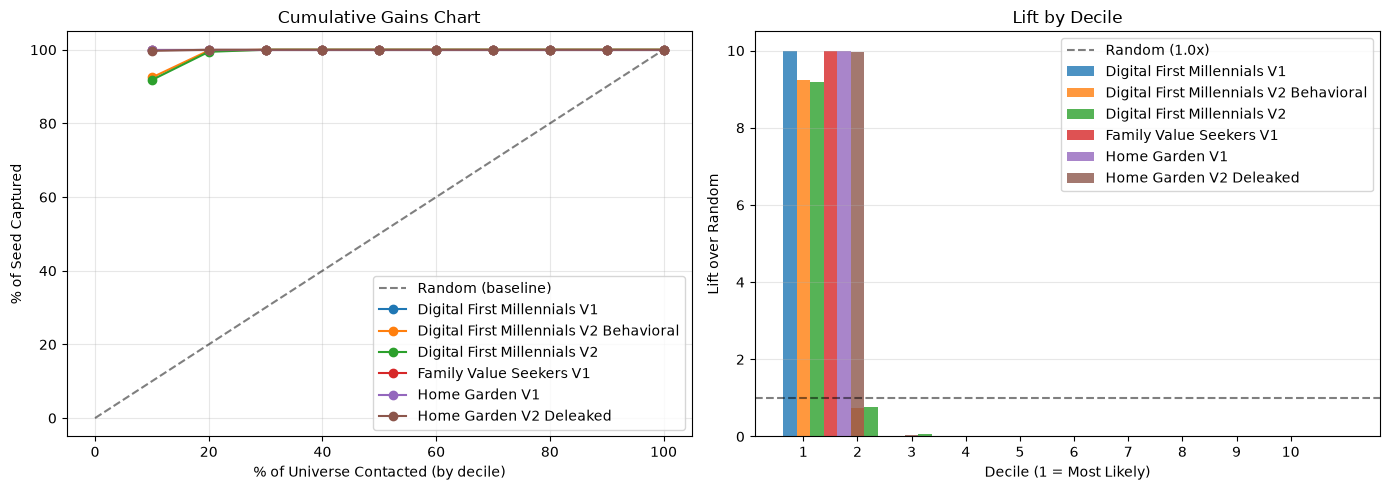


Interpretation: Decile 1 should have lift > 2x (capturing 2x more seed members
than random selection). Higher lift = better model discrimination.


In [25]:
# Cumulative Gains and Lift Charts
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Cumulative Gains
ax1 = axes[0]
ax1.plot([0, 100], [0, 100], 'k--', alpha=0.5, label='Random (baseline)')

for model_name in model_names:
    try:
        lift_df = session.table(f"LOOKALIKE_DEMO.MONITORING.{model_name}_LIFT").to_pandas()
        lift_df = lift_df.sort_values('DECILE')
        total_seed = lift_df['SEED_IN_DECILE'].sum()
        cum_pct = (lift_df['SEED_IN_DECILE'].cumsum() / total_seed * 100).values
        decile_pcts = np.arange(10, 110, 10)
        label = model_name.replace('LOOKALIKE_', '').replace('_', ' ').title()
        ax1.plot(decile_pcts, cum_pct, 'o-', label=label)
    except Exception as e:
        print(f"  Skipping {model_name}: {e}")

ax1.set_xlabel('% of Universe Contacted (by decile)')
ax1.set_ylabel('% of Seed Captured')
ax1.set_title('Cumulative Gains Chart')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Lift by Decile
ax2 = axes[1]
ax2.axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='Random (1.0x)')

bar_width = 0.25
x = np.arange(1, 11)

for i, model_name in enumerate(model_names):
    try:
        lift_df = session.table(f"LOOKALIKE_DEMO.MONITORING.{model_name}_LIFT").to_pandas()
        lift_df = lift_df.sort_values('DECILE')
        total_seed = lift_df['SEED_IN_DECILE'].sum()
        lift_values = (lift_df['SEED_IN_DECILE'] / (total_seed / 10)).values
        label = model_name.replace('LOOKALIKE_', '').replace('_', ' ').title()
        ax2.bar(x + (i - 1) * bar_width, lift_values, bar_width, label=label, alpha=0.8)
    except Exception:
        pass

ax2.set_xlabel('Decile (1 = Most Likely)')
ax2.set_ylabel('Lift over Random')
ax2.set_title('Lift by Decile')
ax2.legend()
ax2.set_xticks(x)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nInterpretation: Decile 1 should have lift > 2x (capturing 2x more seed members")
print("than random selection). Higher lift = better model discrimination.")

## 10. Feature Selection Audit

Validate that the agent's feature choices make intuitive sense for each seed. This is the DS team's "gut check" — do the model's important features align with domain knowledge?

In [26]:
# Feature Selection Audit
# Query experiment parameters to see which features the agent chose per model.
# This is the DS team's "gut check" — do the agent's choices make domain sense?

print("=== Feature Selection Audit ===\n")
print("Review the agent's feature choices for each model.")
print("The agent should have selected features that align with the seed definition.\n")

# Expected signals per seed (what we'd expect a good model to use)
expected_signals = {
    "home_garden": ["HOMEOWNER", "PCT_HOME_GARDEN", "URBANICITY_SCORE", "MAIL_RESPONSE_RATE", "AGE"],
    "digital_first": ["AGE", "EMAIL_OPEN_RATE", "WEB_VISITS_6M", "PCT_ELECTRONICS", "URBANICITY_SCORE"],
    "family_value": ["CHILDREN_COUNT", "HOUSEHOLD_SIZE", "PCT_FOOD", "PCT_TOYS", "COUPON_USAGE_COUNT"]
}

for model_name in model_names:
    label = model_name.replace('LOOKALIKE_', '').replace('_', ' ').title()
    print(f"--- {label} ---")

    # Find matching expected signals
    for key, signals in expected_signals.items():
        if key in model_name.lower():
            print(f"  Expected key signals: {signals}")
            break

    # Show the scored table's columns (features the model was trained on)
    try:
        scored_cols = session.table(f"LOOKALIKE_DEMO.SCORING.{model_name}_SCORED").columns
        print(f"  Scored table columns: {scored_cols}")
    except Exception:
        pass

    print()

=== Feature Selection Audit ===

Review the agent's feature choices for each model.
The agent should have selected features that align with the seed definition.

--- Digital First Millennials V1 ---
  Expected key signals: ['AGE', 'EMAIL_OPEN_RATE', 'WEB_VISITS_6M', 'PCT_ELECTRONICS', 'URBANICITY_SCORE']
  Scored table columns: ['CONSUMER_ID', 'SCORE', 'DECILE']

--- Digital First Millennials V2 Behavioral ---
  Expected key signals: ['AGE', 'EMAIL_OPEN_RATE', 'WEB_VISITS_6M', 'PCT_ELECTRONICS', 'URBANICITY_SCORE']
  Scored table columns: ['CONSUMER_ID', 'SCORE', 'DECILE']

--- Digital First Millennials V2 ---
  Expected key signals: ['AGE', 'EMAIL_OPEN_RATE', 'WEB_VISITS_6M', 'PCT_ELECTRONICS', 'URBANICITY_SCORE']
  Scored table columns: ['CONSUMER_ID', 'SCORE', 'DECILE']

--- Family Value Seekers V1 ---
  Expected key signals: ['CHILDREN_COUNT', 'HOUSEHOLD_SIZE', 'PCT_FOOD', 'PCT_TOYS', 'COUPON_USAGE_COUNT']
  Scored table columns: ['CONSUMER_ID', 'SCORE', 'DECILE']

--- Home Garden 

## 11. PSI Drift Detection

Population Stability Index (PSI) measures whether the scoring distribution has shifted from training. A high PSI indicates the model may need retraining.

In [27]:
# PSI Drift Detection
# Compare decile distributions between the expected (uniform 10% per decile)
# and actual scoring output. In production, compare current scoring vs. training distribution.

def compute_psi(expected_proportions, actual_proportions, epsilon=1e-4):
    """Compute Population Stability Index."""
    expected = np.array(expected_proportions) + epsilon
    actual = np.array(actual_proportions) + epsilon
    psi = np.sum((actual - expected) * np.log(actual / expected))
    return psi

print("=== PSI Drift Detection ===\n")
print("PSI Thresholds: < 0.1 = stable, 0.1-0.2 = moderate drift, > 0.2 = significant drift\n")

for model_name in model_names:
    try:
        scored_df = session.table(f"LOOKALIKE_DEMO.SCORING.{model_name}_SCORED")
        decile_dist = scored_df.group_by("DECILE").count().order_by("DECILE").to_pandas()
        total = decile_dist['COUNT'].sum()
        actual_props = (decile_dist['COUNT'] / total).values

        expected_props = np.full(10, 0.10)
        psi = compute_psi(expected_props, actual_props)

        status = "STABLE" if psi < 0.1 else ("MODERATE DRIFT" if psi < 0.2 else "SIGNIFICANT DRIFT")
        label = model_name.replace('LOOKALIKE_', '').replace('_', ' ').title()
        print(f"  {label}: PSI = {psi:.4f} -> {status}")
    except Exception as e:
        print(f"  Skipping {model_name}: {e}")

print("\nNote: In production, compare scoring distribution against training distribution")
print("over time. Rising PSI indicates the model's assumptions no longer hold.")

=== PSI Drift Detection ===

PSI Thresholds: < 0.1 = stable, 0.1-0.2 = moderate drift, > 0.2 = significant drift

  Digital First Millennials V1: PSI = 0.0000 -> STABLE
  Digital First Millennials V2 Behavioral: PSI = 0.0000 -> STABLE
  Digital First Millennials V2: PSI = 0.0000 -> STABLE
  Family Value Seekers V1: PSI = 0.0000 -> STABLE
  Home Garden V1: PSI = 0.0000 -> STABLE
  Home Garden V2 Deleaked: PSI = 0.0000 -> STABLE

Note: In production, compare scoring distribution against training distribution
over time. Rising PSI indicates the model's assumptions no longer hold.


## 12. Quality Gates

Combine all validation signals into a pass/fail scorecard. Models that pass are tagged APPROVED in the registry; models that fail are flagged for DS review.

In [28]:
# Quality Gates: automated pass/fail for each agent-created model
QUALITY_THRESHOLDS = {
    "min_auc": 0.65,
    "min_lift_d1": 2.0,
    "max_psi": 0.2,
}

print("=== Quality Gate Evaluation ===\n")
print(f"Thresholds: Lift@D1 >= {QUALITY_THRESHOLDS['min_lift_d1']}, "
      f"PSI < {QUALITY_THRESHOLDS['max_psi']}\n")

for model_name in model_names:
    try:
        # Lift check
        lift_df = session.table(f"LOOKALIKE_DEMO.MONITORING.{model_name}_LIFT").to_pandas()
        lift_df = lift_df.sort_values('DECILE')
        total_seed = lift_df['SEED_IN_DECILE'].sum()
        lift_d1 = lift_df.iloc[0]['SEED_IN_DECILE'] / (total_seed / 10)

        # PSI check
        scored_df = session.table(f"LOOKALIKE_DEMO.SCORING.{model_name}_SCORED")
        decile_dist = scored_df.group_by("DECILE").count().order_by("DECILE").to_pandas()
        total = decile_dist['COUNT'].sum()
        actual_props = (decile_dist['COUNT'] / total).values
        psi = compute_psi(np.full(10, 0.10), actual_props)

        checks = {
            "Lift@D1 >= 2.0": lift_d1 >= QUALITY_THRESHOLDS['min_lift_d1'],
            "PSI < 0.2": psi < QUALITY_THRESHOLDS['max_psi'],
        }

        all_pass = all(checks.values())
        verdict = "APPROVED" if all_pass else "NEEDS_REVIEW"

        label = model_name.replace('LOOKALIKE_', '').replace('_', ' ').title()
        print(f"--- {label} ---")
        print(f"  Lift@D1: {lift_d1:.2f}x, PSI: {psi:.4f}")
        for check_name, passed in checks.items():
            symbol = "PASS" if passed else "FAIL"
            print(f"  [{symbol}] {check_name}")
        print(f"  Verdict: {verdict}\n")

    except Exception as e:
        print(f"  Skipping {model_name}: {e}\n")

=== Quality Gate Evaluation ===

Thresholds: Lift@D1 >= 2.0, PSI < 0.2

--- Digital First Millennials V1 ---
  Lift@D1: 10.00x, PSI: 0.0000
  [PASS] Lift@D1 >= 2.0
  [PASS] PSI < 0.2
  Verdict: APPROVED

--- Digital First Millennials V2 Behavioral ---
  Lift@D1: 9.25x, PSI: 0.0000
  [PASS] Lift@D1 >= 2.0
  [PASS] PSI < 0.2
  Verdict: APPROVED

--- Digital First Millennials V2 ---
  Lift@D1: 9.18x, PSI: 0.0000
  [PASS] Lift@D1 >= 2.0
  [PASS] PSI < 0.2
  Verdict: APPROVED

--- Family Value Seekers V1 ---
  Lift@D1: 10.00x, PSI: 0.0000
  [PASS] Lift@D1 >= 2.0
  [PASS] PSI < 0.2
  Verdict: APPROVED

--- Home Garden V1 ---
  Lift@D1: 10.00x, PSI: 0.0000
  [PASS] Lift@D1 >= 2.0
  [PASS] PSI < 0.2
  Verdict: APPROVED

--- Home Garden V2 Deleaked ---
  Lift@D1: 9.97x, PSI: 0.0000
  [PASS] Lift@D1 >= 2.0
  [PASS] PSI < 0.2
  Verdict: APPROVED



## 13. Summary & Next Steps

### What We Built

**Part 1 — The Agent Side:**
- A governed **Feature Store** with 5 feature views (demographics, RFM, category affinity, channel engagement, geo density)
- A **Cortex Agent skill** (`SKILL.md`) that orchestrates intelligent lookalike modeling via generic tools backed by stored procedures
- An **agent** that combines LLM reasoning (interpreting seed profiles) with statistical validation (MI, correlation) to select features from the Feature Store
- Three models created by the agent, each with different feature selections tailored to the seed audience

**Part 2 — The DS Monitoring Side:**
- **Experiment dashboard** for side-by-side model comparison
- **Cumulative gains & lift analysis** to validate model discrimination
- **Feature selection audit** to verify the agent's choices align with domain knowledge
- **PSI drift detection** to identify when models need retraining
- **Automated quality gates** with pass/fail thresholds and registry tagging

### Snowflake Capabilities Demonstrated

| Capability | How Used |
|---|---|
| Feature Store | Governed feature catalog the agent browses; `generate_training_set()` for point-in-time features |
| Cortex Agent Skills | `SKILL.md` with multi-step orchestration; generic tools backed by stored procedures |
| Model Registry | Versioned model storage with metrics and comments |
| Experiment Tracking | Per-run logging of parameters, metrics, and feature selections |
| XGBoost (server-side) | Binary classification for seed vs. non-seed |

### Next Steps

1. **Streamlit Monitoring Dashboard** — Build a visual interface for the DS team to monitor all agent-created models in real-time
2. **Feature Store Online Serving** — Enable sub-second feature retrieval for real-time scoring
3. **Automated Retraining** — Use Tasks to trigger model refresh when PSI exceeds threshold
4. **Skill Enhancement** — Add derived feature engineering capabilities (category ratios, interaction terms, binning)
5. **Agent Evaluation** — Once skills are supported in evals, build an evaluation dataset to measure feature selection quality

### Customer Connection

This module addresses the workflow described by Quad/Rise's data science team:
- Non-technical users trigger models via the agent (their "5-minute lookalike" vision)
- 750+ monthly models monitored at scale via experiments and quality gates
- DS team "gut-checks" agent decisions via feature selection audit
- Feature Store prevents drift: governed definitions, consistent features across all models

In [29]:
# Clean up temp files
import shutil
shutil.rmtree(skill_dir, ignore_errors=True)
print("Lab complete. Skill files are stored on @LOOKALIKE_DEMO.MODELS.SKILL_STAGE.")

Lab complete. Skill files are stored on @LOOKALIKE_DEMO.MODELS.SKILL_STAGE.
